# Modelos PyTorch — Classificação de Texto AI vs Human

Este notebook permite treinar e avaliar os modelos PyTorch implementados em `models/pytorch_models/`.

**Modelos disponíveis:**
- **Baseline** — Regressão Logística (TF-IDF)
- **DNN** — Deep Feedforward Network (TF-IDF)
- **LSTM** — Bidirectional LSTM com Embeddings
- **GRU** — Bidirectional GRU com Embeddings

**Classes:** Anthropic | Google | Human | Meta | OpenAI

## 0. Setup — Imports e Configuração

In [4]:
import sys
sys.path.append('../models/pytorch_models')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from dataset import TfidfDataset, SequenceDataset, clean_text, build_vocab
from models import BaselineClassifier, DNNClassifier, LSTMClassifier, GRUClassifier
from train import train, evaluate, predict, DEVICE

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch version: 2.10.0+cu128
Device: cpu


In [5]:
# Hiperparâmetros 

CLASSES       = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
N_CLASSES     = len(CLASSES)

TFIDF_WORDS   = 2000     # tamanho do vocabulário TF-IDF
MAX_LEN       = 150      # comprimento máximo de sequência (RNN/LSTM/GRU)
MAX_VOCAB     = 10000    # tamanho do vocabulário para embeddings
EMBED_DIM     = 128      # dimensão dos embeddings
HIDDEN_DIM    = 128      # dimensão do estado oculto das RNNs

BATCH_SIZE    = 64
EPOCHS        = 100
LR            = 0.001
PATIENCE      = 10       # early stopping

TEST_SIZE     = 0.2
VAL_SIZE      = 0.1
RANDOM_STATE  = 42

print("Configuração carregada!")

Configuração carregada!


## 1. Carregar e Preparar os Dados

- **Treino + Validação:** `dataset_limpo.csv`
- **Teste final:** `dataset-exemplos.csv` (como no notebook NumPy)

Total de exemplos (dataset_limpo): 4995

Distribuição por classe (dataset_limpo):


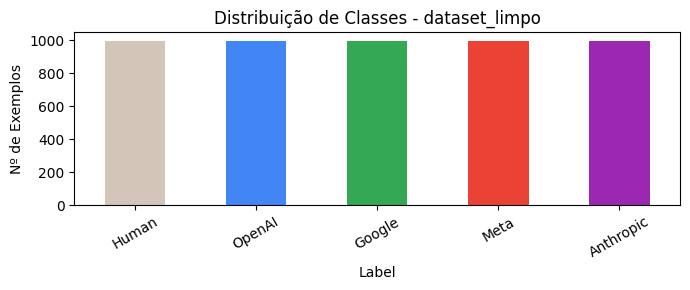


Total de exemplos (dataset-exemplos): 125
Distribuição por classe (dataset-exemplos):
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64


In [6]:
# Carregar datasets
df = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])
df_exemplos = pd.read_csv('../data/dataset-exemplos.csv', sep=';').dropna(subset=['Text', 'Label'])

label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

texts  = df['Text'].tolist()
labels = [label2idx[l] for l in df['Label']]

print(f"Total de exemplos (dataset_limpo): {len(texts)}")
print("\nDistribuição por classe (dataset_limpo):")
df['Label'].value_counts().plot(kind='bar', color=['#D4C5B9', '#4285F4', '#34A853', '#EA4335', '#9C27B0'],
                                 figsize=(7, 3), title='Distribuição de Classes - dataset_limpo')
plt.ylabel('Nº de Exemplos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"\nTotal de exemplos (dataset-exemplos): {len(df_exemplos)}")
print("Distribuição por classe (dataset-exemplos):")
print(df_exemplos['Label'].value_counts())

In [7]:
# Split treino / validação (teste externo = dataset-exemplos)
X_tr, X_val, y_tr, y_val = train_test_split(
    texts, labels, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=labels)

# Teste externo (dataset do professor), sem entrar no treino/validação
X_te = df_exemplos['Text'].tolist()
y_te = [label2idx[l] for l in df_exemplos['Label']]

print(f"Treino:    {len(X_tr)} exemplos")
print(f"Validação: {len(X_val)} exemplos")
print(f"Teste (externo - professor): {len(X_te)} exemplos")

Treino:    4495 exemplos
Validação: 500 exemplos
Teste (externo - professor): 125 exemplos


In [8]:
# Datasets TF-IDF (para Baseline e DNN)
train_ds_tfidf = TfidfDataset(X_tr,  y_tr,  max_words=TFIDF_WORDS, train=True)
val_ds_tfidf   = TfidfDataset(X_val, y_val, vectorizer=train_ds_tfidf.vectorizer, train=False)
test_ds_tfidf  = TfidfDataset(X_te,  y_te,  vectorizer=train_ds_tfidf.vectorizer, train=False)

train_loader_tfidf = DataLoader(train_ds_tfidf, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tfidf   = DataLoader(val_ds_tfidf,   batch_size=BATCH_SIZE)
test_loader_tfidf  = DataLoader(test_ds_tfidf,  batch_size=BATCH_SIZE)

# Datasets de Sequências (para LSTM / GRU)
clean_tr  = [clean_text(t) for t in X_tr]
word_index = build_vocab(clean_tr, max_words=MAX_VOCAB)
vocab_size = len(word_index) + 2

train_ds_seq = SequenceDataset(X_tr,  y_tr,  word_index, max_len=MAX_LEN)
val_ds_seq   = SequenceDataset(X_val, y_val, word_index, max_len=MAX_LEN)
test_ds_seq  = SequenceDataset(X_te,  y_te,  word_index, max_len=MAX_LEN)

train_loader_seq = DataLoader(train_ds_seq, batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq   = DataLoader(val_ds_seq,   batch_size=BATCH_SIZE)
test_loader_seq  = DataLoader(test_ds_seq,  batch_size=BATCH_SIZE)

print(f"Vocabulário (Embeddings): {vocab_size} palavras")
print("Conjunto de teste externo configurado a partir de dataset-exemplos.csv")

Vocabulário (Embeddings): 10002 palavras
Conjunto de teste externo configurado a partir de dataset-exemplos.csv


## Funções de Visualização

In [9]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Treino',    color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Validação', color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Treino',    color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Validação', color='tomato')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion(model, loader, title='Matriz de Confusão'):
    preds = predict(model, loader).numpy()
    true  = [int(y) for _, y in loader.dataset]
    cm = confusion_matrix(true, preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title, fontweight='bold')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.tight_layout()
    plt.show()

    print(classification_report(true, preds, target_names=CLASSES))


---
## 2. Baseline — Regressão Logística (TF-IDF)

In [10]:
baseline = BaselineClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES)
criterion = nn.CrossEntropyLoss()

print("A treinar a Baseline (Regressão Logística + TF-IDF)...")
history_base = train(baseline, train_loader_tfidf, val_loader_tfidf, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar a Baseline (Regressão Logística + TF-IDF)...
Epoch 1/100 | train_loss: 1.5472 | train_acc: 0.6932 | val_loss: 1.5520 | val_acc: 0.6040
Epoch 2/100 | train_loss: 1.4916 | train_acc: 0.7453 | val_loss: 1.5018 | val_acc: 0.6700
Epoch 3/100 | train_loss: 1.4405 | train_acc: 0.7846 | val_loss: 1.4554 | val_acc: 0.7020
Epoch 4/100 | train_loss: 1.3922 | train_acc: 0.7960 | val_loss: 1.4127 | val_acc: 0.7180
Epoch 5/100 | train_loss: 1.3471 | train_acc: 0.8113 | val_loss: 1.3725 | val_acc: 0.7480
Epoch 6/100 | train_loss: 1.3059 | train_acc: 0.8162 | val_loss: 1.3360 | val_acc: 0.7460
Epoch 7/100 | train_loss: 1.2674 | train_acc: 0.8247 | val_loss: 1.3018 | val_acc: 0.7500
Epoch 8/100 | train_loss: 1.2322 | train_acc: 0.8331 | val_loss: 1.2700 | val_acc: 0.7600
Epoch 9/100 | train_loss: 1.1959 | train_acc: 0.8396 | val_loss: 1.2400 | val_acc: 0.7680
Epoch 10/100 | train_loss: 1.1619 | train_acc: 0.8425 | val_loss: 1.2119 | val_acc: 0.7580
Epoch 11/100 | train_loss: 1.1316 | train_ac

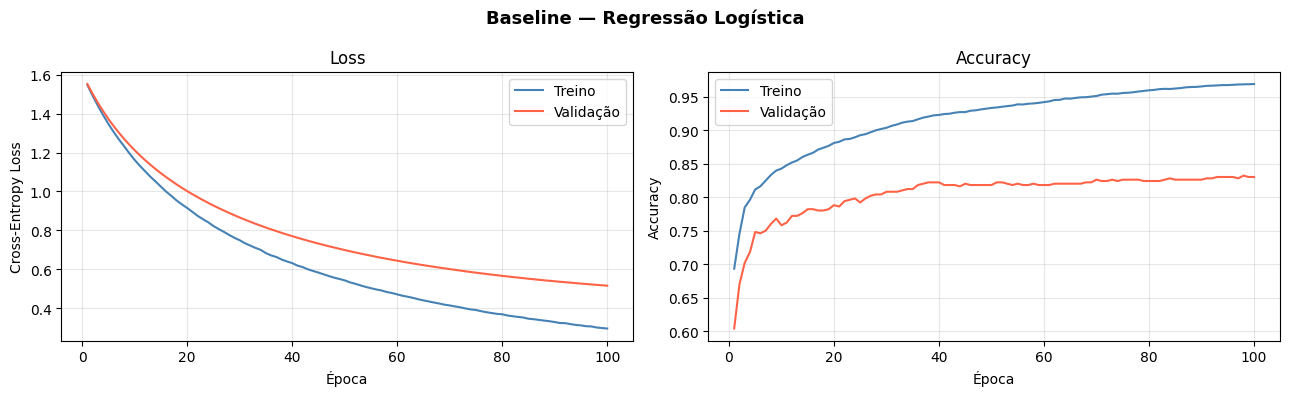


Accuracy no Teste (Baseline): 53.60%


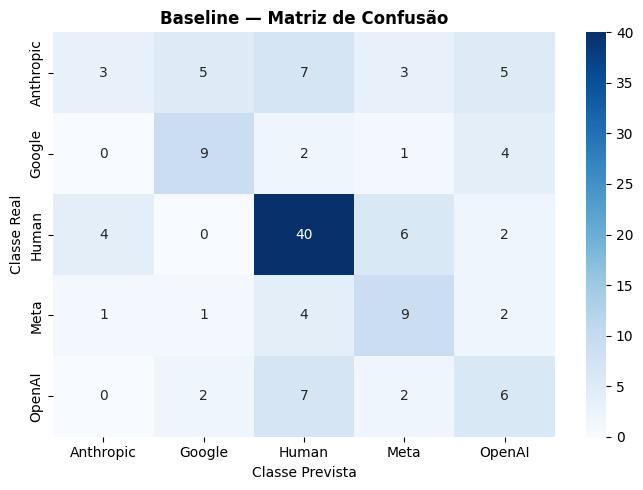

              precision    recall  f1-score   support

   Anthropic       0.38      0.13      0.19        23
      Google       0.53      0.56      0.55        16
       Human       0.67      0.77      0.71        52
        Meta       0.43      0.53      0.47        17
      OpenAI       0.32      0.35      0.33        17

    accuracy                           0.54       125
   macro avg       0.46      0.47      0.45       125
weighted avg       0.52      0.54      0.51       125



In [11]:
plot_history(history_base, 'Baseline — Regressão Logística')
_, acc_base = evaluate(baseline, test_loader_tfidf)
print(f"\nAccuracy no Teste (Baseline): {acc_base*100:.2f}%")
plot_confusion(baseline, test_loader_tfidf, 'Baseline — Matriz de Confusão')

---
## 3. DNN — Deep Feedforward Network (TF-IDF)

In [12]:
dnn = DNNClassifier(
    input_dim=TFIDF_WORDS,
    n_classes=N_CLASSES,
    topology=[256, 128, 64],   # camadas ocultas
    dropout=0.3
)

print("A treinar DNN (TF-IDF)...")
history_dnn = train(dnn, train_loader_tfidf, val_loader_tfidf, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar DNN (TF-IDF)...
Epoch 1/100 | train_loss: 1.1336 | train_acc: 0.4625 | val_loss: 1.1543 | val_acc: 0.4380
Epoch 2/100 | train_loss: 0.4051 | train_acc: 0.8665 | val_loss: 0.5214 | val_acc: 0.8200
Epoch 3/100 | train_loss: 0.2330 | train_acc: 0.9235 | val_loss: 0.4696 | val_acc: 0.8140
Epoch 4/100 | train_loss: 0.1412 | train_acc: 0.9593 | val_loss: 0.4816 | val_acc: 0.8260
Epoch 5/100 | train_loss: 0.0851 | train_acc: 0.9755 | val_loss: 0.5346 | val_acc: 0.8120
Epoch 6/100 | train_loss: 0.0529 | train_acc: 0.9884 | val_loss: 0.5740 | val_acc: 0.8220
Epoch 7/100 | train_loss: 0.0350 | train_acc: 0.9942 | val_loss: 0.6868 | val_acc: 0.8060
Epoch 8/100 | train_loss: 0.0231 | train_acc: 0.9962 | val_loss: 0.6986 | val_acc: 0.8100
Epoch 9/100 | train_loss: 0.0146 | train_acc: 0.9971 | val_loss: 0.7431 | val_acc: 0.8080
Epoch 10/100 | train_loss: 0.0104 | train_acc: 0.9989 | val_loss: 0.8033 | val_acc: 0.8180
Epoch 11/100 | train_loss: 0.0069 | train_acc: 0.9996 | val_loss: 0.8148 

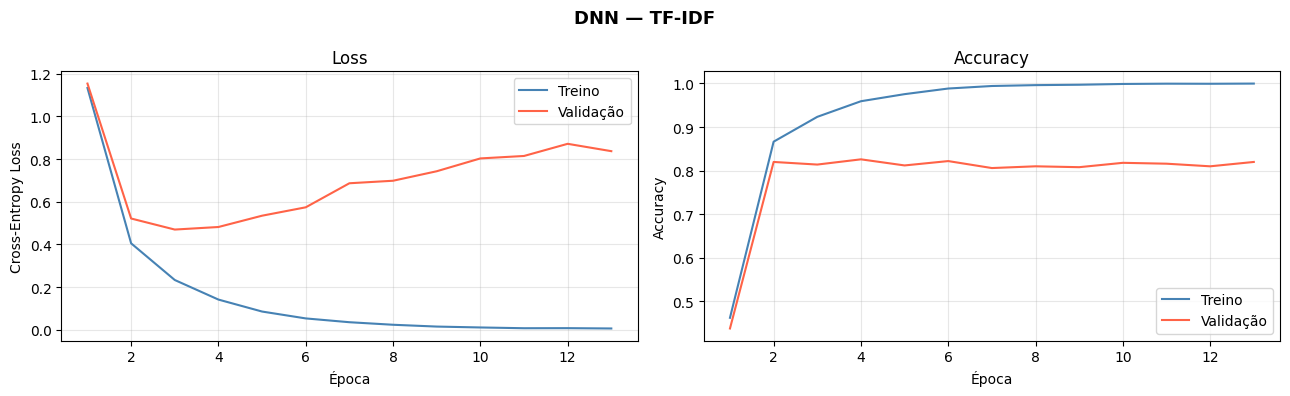


Accuracy no Teste (DNN): 46.40%


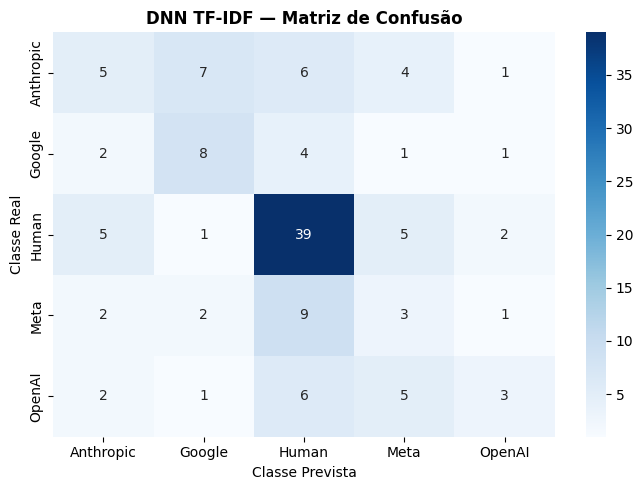

              precision    recall  f1-score   support

   Anthropic       0.31      0.22      0.26        23
      Google       0.42      0.50      0.46        16
       Human       0.61      0.75      0.67        52
        Meta       0.17      0.18      0.17        17
      OpenAI       0.38      0.18      0.24        17

    accuracy                           0.46       125
   macro avg       0.38      0.36      0.36       125
weighted avg       0.44      0.46      0.44       125



In [13]:
plot_history(history_dnn, 'DNN — TF-IDF')
_, acc_dnn = evaluate(dnn, test_loader_tfidf)
print(f"\nAccuracy no Teste (DNN): {acc_dnn*100:.2f}%")
plot_confusion(dnn, test_loader_tfidf, 'DNN TF-IDF — Matriz de Confusão')

---
## 4. BiLSTM — Embeddings

In [14]:
lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiLSTM (Embeddings)...")
history_lstm = train(lstm, train_loader_seq, val_loader_seq, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiLSTM (Embeddings)...
Epoch 1/100 | train_loss: 1.0639 | train_acc: 0.5566 | val_loss: 1.1231 | val_acc: 0.5080
Epoch 2/100 | train_loss: 0.8651 | train_acc: 0.6220 | val_loss: 1.0067 | val_acc: 0.5640


KeyboardInterrupt: 

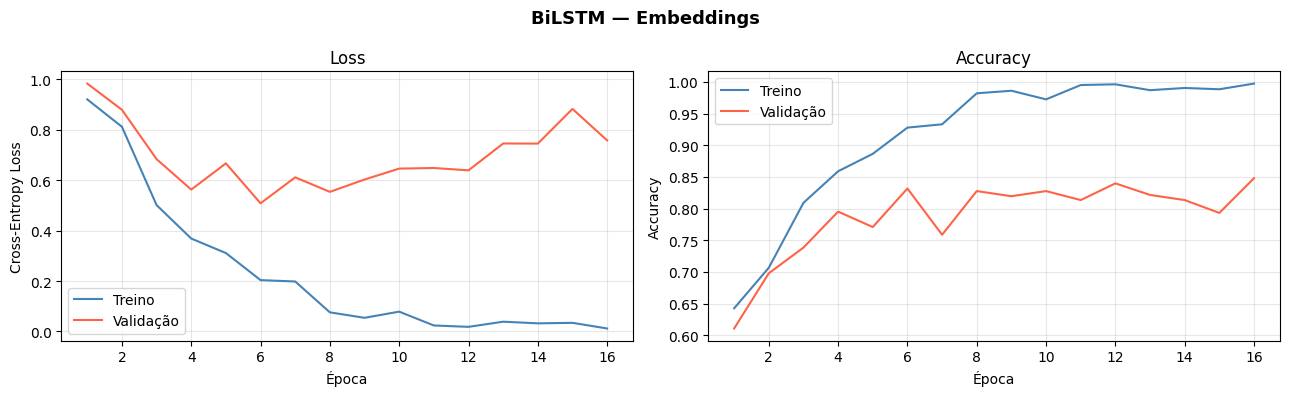


Accuracy no Teste (BiLSTM): 79.84%


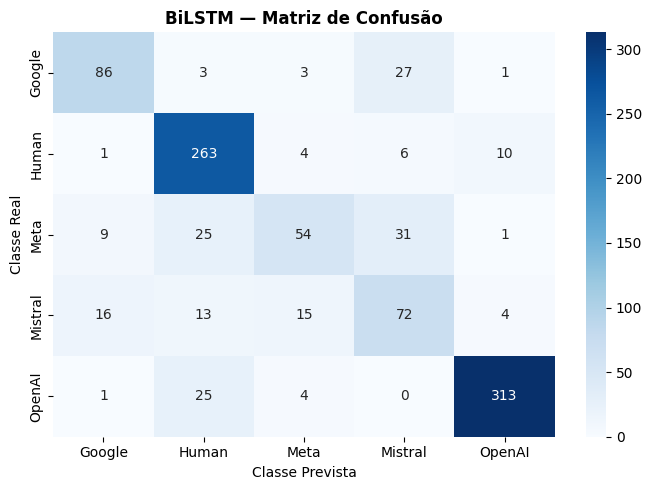

              precision    recall  f1-score   support

      Google       0.76      0.72      0.74       120
       Human       0.80      0.93      0.86       284
        Meta       0.68      0.45      0.54       120
     Mistral       0.53      0.60      0.56       120
      OpenAI       0.95      0.91      0.93       343

    accuracy                           0.80       987
   macro avg       0.74      0.72      0.73       987
weighted avg       0.80      0.80      0.79       987



In [13]:
plot_history(history_lstm, 'BiLSTM — Embeddings')
_, acc_lstm = evaluate(lstm, test_loader_seq)
print(f"\nAccuracy no Teste (BiLSTM): {acc_lstm*100:.2f}%")
plot_confusion(lstm, test_loader_seq, 'BiLSTM — Matriz de Confusão')

---
## 5. BiGRU — Embeddings

In [15]:
gru = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiGRU (Embeddings)...")
history_gru = train(gru, train_loader_seq, val_loader_seq, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiGRU (Embeddings)...
Epoch 1/100 | train_loss: 1.0178 | train_acc: 0.5575 | val_loss: 1.0747 | val_acc: 0.5300
Epoch 2/100 | train_loss: 0.6015 | train_acc: 0.7615 | val_loss: 0.7095 | val_acc: 0.7020
Epoch 3/100 | train_loss: 0.3701 | train_acc: 0.8607 | val_loss: 0.5096 | val_acc: 0.7920
Epoch 4/100 | train_loss: 0.2465 | train_acc: 0.9090 | val_loss: 0.4982 | val_acc: 0.8180
Epoch 5/100 | train_loss: 0.1044 | train_acc: 0.9700 | val_loss: 0.4167 | val_acc: 0.8600
Epoch 6/100 | train_loss: 0.1459 | train_acc: 0.9442 | val_loss: 0.4931 | val_acc: 0.8360
Epoch 7/100 | train_loss: 0.0335 | train_acc: 0.9933 | val_loss: 0.4304 | val_acc: 0.8700
Epoch 8/100 | train_loss: 0.0281 | train_acc: 0.9911 | val_loss: 0.5012 | val_acc: 0.8640
Epoch 9/100 | train_loss: 0.0340 | train_acc: 0.9895 | val_loss: 0.4808 | val_acc: 0.8680
Epoch 10/100 | train_loss: 0.0052 | train_acc: 0.9996 | val_loss: 0.4920 | val_acc: 0.8640
Epoch 11/100 | train_loss: 0.0115 | train_acc: 0.9973 | val_loss: 0

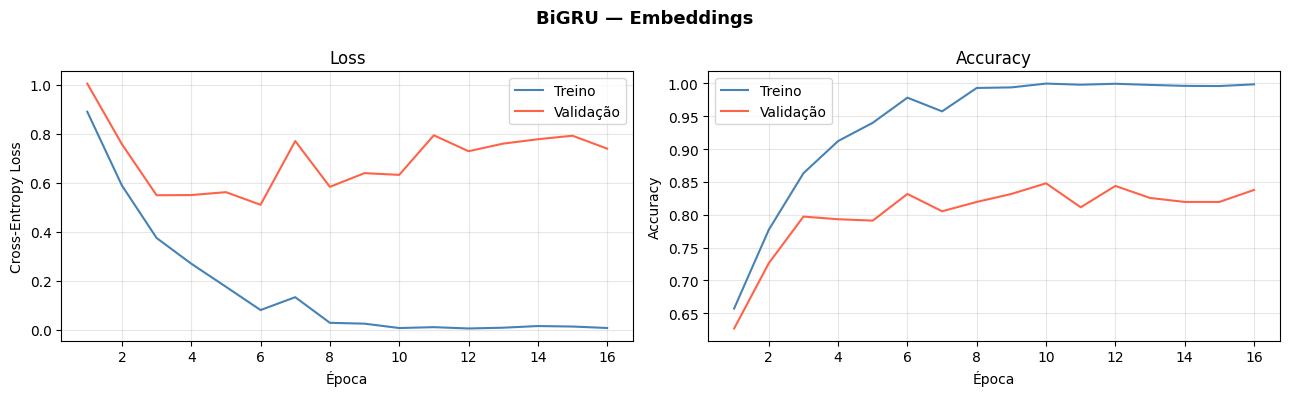


Accuracy no Teste (BiGRU): 80.65%


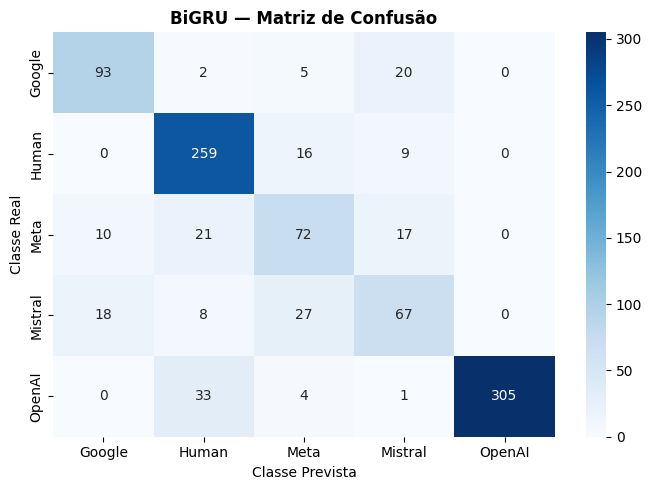

              precision    recall  f1-score   support

      Google       0.77      0.78      0.77       120
       Human       0.80      0.91      0.85       284
        Meta       0.58      0.60      0.59       120
     Mistral       0.59      0.56      0.57       120
      OpenAI       1.00      0.89      0.94       343

    accuracy                           0.81       987
   macro avg       0.75      0.75      0.75       987
weighted avg       0.81      0.81      0.81       987



In [15]:
plot_history(history_gru, 'BiGRU — Embeddings')
_, acc_gru = evaluate(gru, test_loader_seq)
print(f"\nAccuracy no Teste (BiGRU): {acc_gru*100:.2f}%")
plot_confusion(gru, test_loader_seq, 'BiGRU — Matriz de Confusão')

---
## 6. Comparação Final dos Modelos


 COMPARAÇÃO DE MODELOS — Accuracy no Teste
  Baseline (LogReg)      86.32%  ██████████████████████████████████
  DNN (TF-IDF)           86.22%  ██████████████████████████████████
  BiGRU                  80.65%  ████████████████████████████████
  BiLSTM                 79.84%  ███████████████████████████████


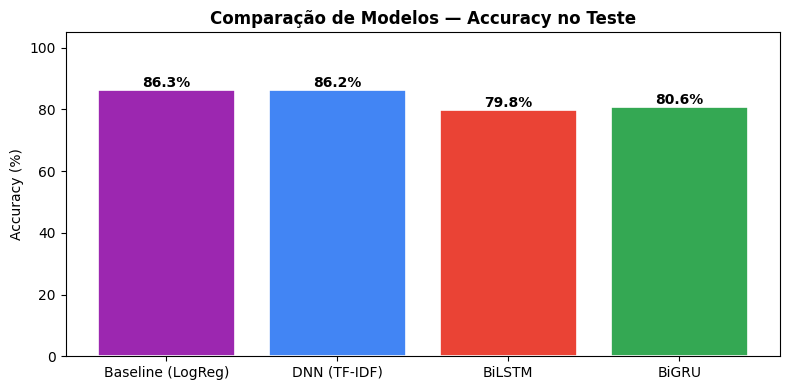

In [16]:
resultados = {
    'Baseline (LogReg)': acc_base,
    'DNN (TF-IDF)':      acc_dnn,
    'BiLSTM':            acc_lstm,
    'BiGRU':             acc_gru,
}

print("\n" + "="*45)
print(" COMPARAÇÃO DE MODELOS — Accuracy no Teste")
print("="*45)
for nome, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"  {nome:<22} {acc*100:5.2f}%  {bar}")
print("="*45)

# Gráfico de barras
plt.figure(figsize=(8, 4))
nomes = list(resultados.keys())
accs  = [v * 100 for v in resultados.values()]
cores = ['#9C27B0', '#4285F4', '#EA4335', '#34A853']
bars  = plt.bar(nomes, accs, color=cores, edgecolor='white', linewidth=1.2)
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Comparação de Modelos — Accuracy no Teste', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Guardar os Modelos

In [17]:
import os
save_dir = '../models/pytorch_models/saved_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(baseline.state_dict(), f'{save_dir}/baseline.pt')
torch.save(dnn.state_dict(),      f'{save_dir}/dnn_tfidf.pt')
torch.save(lstm.state_dict(),     f'{save_dir}/bilstm.pt')
torch.save(gru.state_dict(),      f'{save_dir}/bigru.pt')

print("Modelos guardados em:", save_dir)

Modelos guardados em: ../models/pytorch_models/saved_models


---
## 8. Carregar e Usar um Modelo Guardado

In [18]:
# Exemplo: carregar o DNN e classifcar um texto novo
model_loaded = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_loaded.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', weights_only=True))
model_loaded.eval()

def classificar_texto(texto: str) -> str:
    x = train_ds_tfidf.vectorizer.transform([texto]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = model_loaded(x_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()
    pred_idx = probs.argmax().item()
    print(f"Classe prevista: {CLASSES[pred_idx]}")
    print("Probabilidades:")
    for cls, p in zip(CLASSES, probs.tolist()):
        bar = '█' * int(p * 30)
        print(f"  {cls:<10} {p*100:5.1f}%  {bar}")
    return CLASSES[pred_idx]

# Testar com um texto
texto_teste = "The carbon cycle is a biogeochemical cycle where carbon is exchanged between the Earth's biosphere, atmosphere, and oceans."
classificar_texto(texto_teste)

Classe prevista: Human
Probabilidades:
  Google       0.0%  
  Human      100.0%  █████████████████████████████
  Meta         0.0%  
  Mistral      0.0%  
  OpenAI       0.0%  


'Human'

---
## 9. Gerar Ficheiro de Submissão B (PyTorch)

Este passo lê o ficheiro `subm1.csv`, que contém apenas os textos de teste sem labels, carrega um dos modelos PyTorch treinados (neste caso, o **DNN**) e prevê a classe para cada texto. O resultado é depois exportado para `Subm1/subm1-g3-MIA-B.csv`.

In [ ]:
import os
import pandas as pd
import torch

# 1. Ler o ficheiro de teste
subm_path = '../subm1.csv'
df_subm = pd.read_csv(subm_path, sep=';')

# 2. Certificar que a classe 'Mistral' foi removida das features de teste
# Transformar os textos usando o vectorizer TF-IDF já ajustado (train_ds_tfidf)
X_subm_tfidf = train_ds_tfidf.vectorizer.transform(df_subm['Text']).toarray()

# 3. Carregar o modelo guardado (DNN é o mais robusto do TF-IDF em Accuracy)
model_subm = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_subm.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', map_location=torch.device('cpu'), weights_only=True))
model_subm.eval()

# 4. Fazer predições
X_subm_tensor = torch.tensor(X_subm_tfidf, dtype=torch.float32)
with torch.no_grad():
    logits_subm = model_subm(X_subm_tensor)
    probs_subm = torch.softmax(logits_subm, dim=1)
    preds_idx = probs_subm.argmax(dim=1).numpy()

# 5. Mapear os indíces para as labels correspondentes
predicted_labels = [idx2label[idx] for idx in preds_idx]

# 6. Criar o DataFrame final
df_final_b = pd.DataFrame({
    'ID': df_subm['ID'],
    'Text': df_subm['Text'],
    'Label': predicted_labels
})

# 7. Guardar no diretório Subm1
output_dir = '../Subm1'
os.makedirs(output_dir, exist_ok=True)
output_filename = os.path.join(output_dir, 'subm1-g3-MIA-B.csv')

df_final_b.to_csv(output_filename, sep=';', index=False)

print(f"Ficheiro de submissão criado com sucesso: {output_filename}")
print(df_final_b.head())
